# Project Overview
Use the iris dataset for this exercise:


from sklearn.datasets import load_iris


iris = load_iris()   

- Create a Pandas dataframe from the dataset.
- Print a table with the feature_names as column names, plus variety.
- Print statistics of the features (max, min, avg, etc.).
- Plot a graph showing the relationship between petal width and length.
- Plot a graph showing the relationship between sepal width and length.
- Add colors to point the variety (Virginica, Setosa, Versicolor) of each feature (width, length).
- Add any other graph you find useful to see how to split the data in categories.
- Write down comments supporting your thoughts.

<center>

![iris.png](/workspaces/challenge_ds/iris.png)

</center>

# Import Libraries

In [1]:
# standard
import numpy as np
import pandas as pd
import time

# plots
import matplotlib.pyplot as plt
import seaborn as sns

# other
from sklearn.datasets import load_iris

# Dataset Description

In [2]:
iris = load_iris()

In [7]:
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [9]:
print(iris.feature_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [6]:
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

# Create a Pandas dataframe from the dataset.

In [13]:
print(type(iris))

<class 'sklearn.utils._bunch.Bunch'>


In [14]:
print("Feature Names:", iris.feature_names)
print("Target Names:", iris.target_names)

Feature Names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target Names: ['setosa' 'versicolor' 'virginica']


In [15]:
df_iris = pd.DataFrame(data=iris.data, columns=iris.feature_names)

In [16]:
df_iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


# Print a table with the feature_names as column names, plus variety.

In [27]:
df_iris['target'] = iris['target']

In [28]:
for tg, tg_name in zip([0,1,2], iris['target_names']):
    print(tg, tg_name)

0 setosa
1 versicolor
2 virginica


In [29]:
# Print a table with the feature_names as column names, plus variety.
df_iris.head(3)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_names
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa


In [31]:
# Agrego por el nombre de los target en otra columna 
mapeo = dict(zip(df_iris['target'].unique(),iris['target_names']))
df_iris['target_names'] = df_iris['target'].map(mapeo)
df_iris

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_names
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica


# Print statistics of the features (max, min, avg, etc.).

In [32]:
df_iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   target_names       150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [33]:
df_iris.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


# Plot a graph showing the relationship between petal width and length.

Text(0.5, 1.0, 'Relationship between petal width and length')

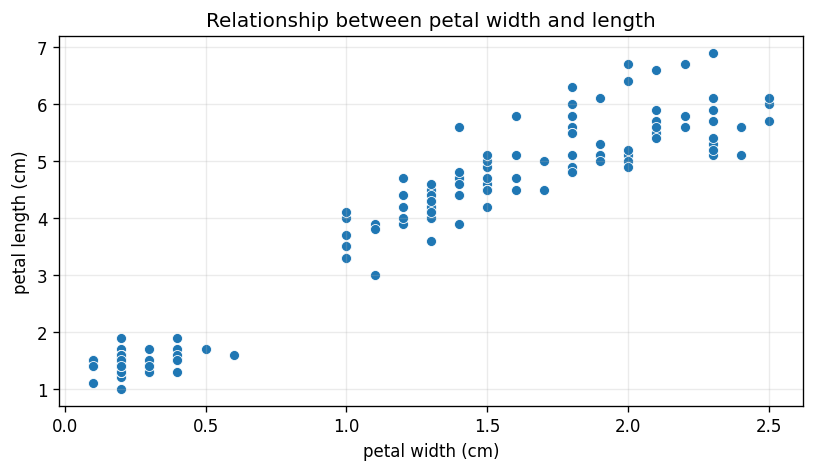

In [37]:
plt.figure(figsize=(8,4), dpi=120)
sns.scatterplot(data= df_iris,
                x='petal width (cm)',
                y='petal length (cm)',
                )
plt.grid(alpha=0.25)
plt.title('Relationship between petal width and length')

# Plot a graph showing the relationship between sepal width and length.

Text(0.5, 1.0, 'Relationship between sepal width and length')

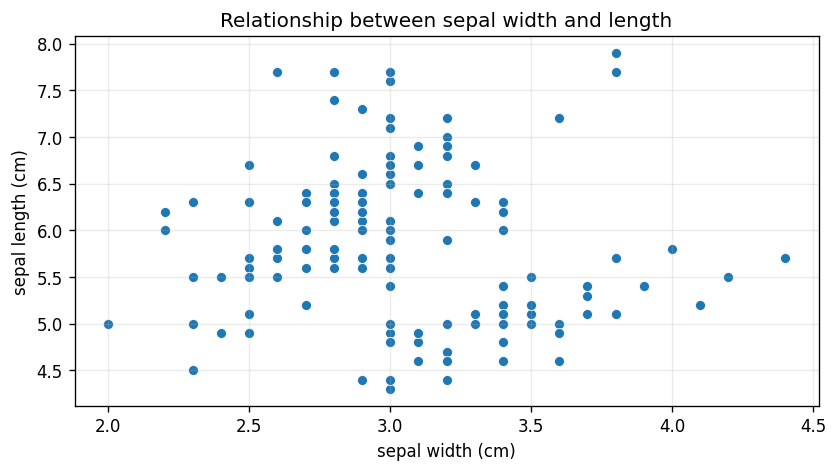

In [38]:
plt.figure(figsize=(8,4), dpi=120)
sns.scatterplot(data= df_iris,
                x='sepal width (cm)',
                y='sepal length (cm)',
                )
plt.grid(alpha=0.25)
plt.title('Relationship between sepal width and length')

# Add colors to point the variety (Virginica, Setosa, Versicolor) of each feature (width, length).

Text(0.5, 1.0, 'Relationship between petal width and length')

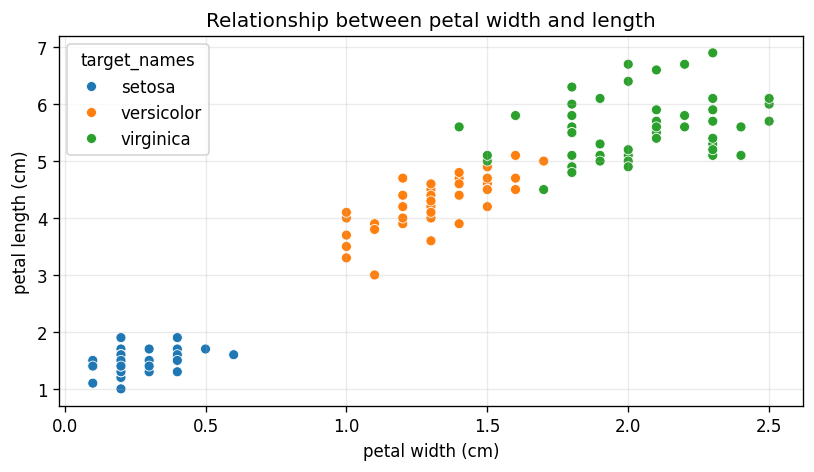

In [40]:
plt.figure(figsize=(8,4), dpi=120)
sns.scatterplot(data= df_iris,
                x='petal width (cm)',
                y='petal length (cm)', 
                hue = 'target_names'
                )
plt.grid(alpha=0.25)
plt.title('Relationship between petal width and length')

Text(0.5, 1.0, 'Relationship between sepal width and length')

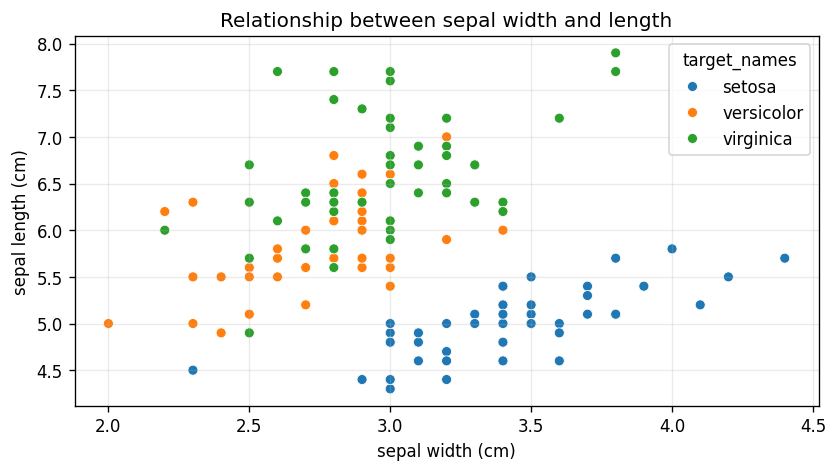

In [42]:
plt.figure(figsize=(8,4), dpi=120)
sns.scatterplot(data= df_iris,
                x='sepal width (cm)',
                y='sepal length (cm)',
                hue='target_names'
                )
plt.grid(alpha=0.25)
plt.title('Relationship between sepal width and length')

# Add any other graph you find useful to see how to split the data in categories.

<Axes: xlabel='target_names', ylabel='count'>

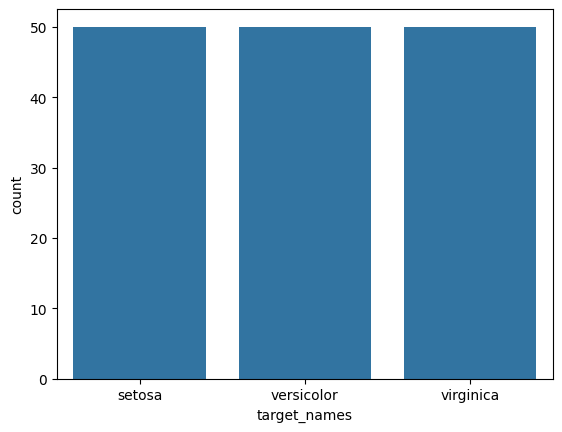

In [43]:
sns.countplot(x='target_names',data=df_iris)

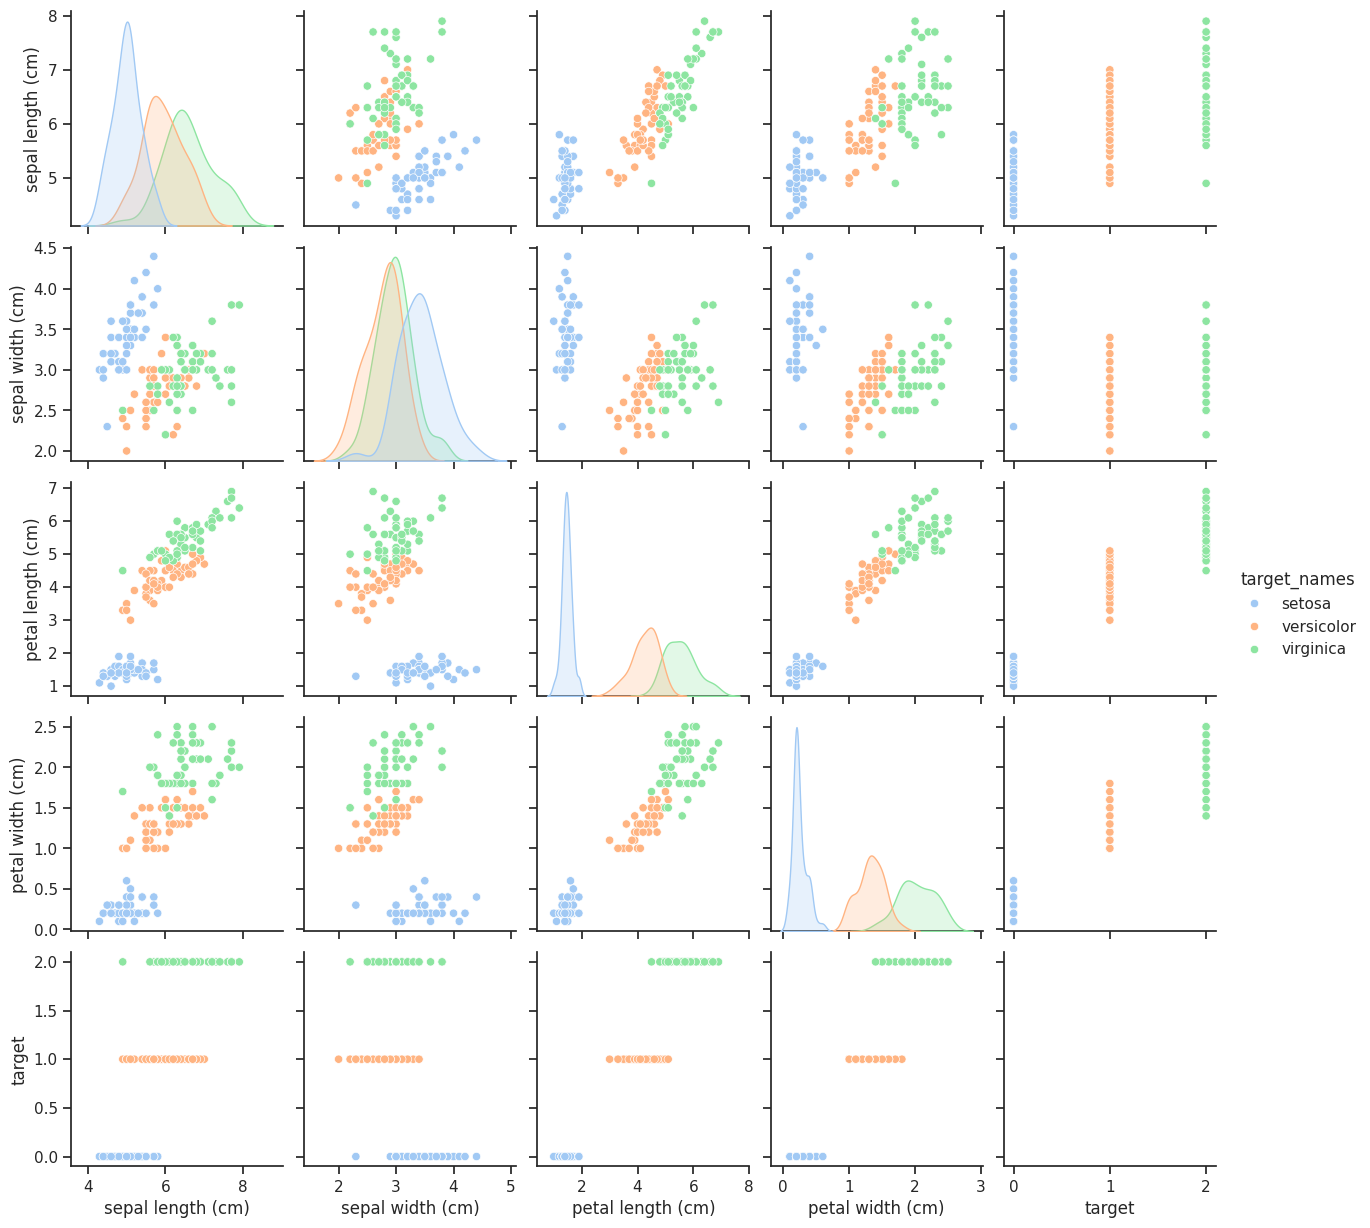

In [64]:
sns.pairplot(df_iris, hue="target_names")

In [49]:
# Seleccionar solo las columnas numéricas
numerical_iris = df_iris.select_dtypes(include='number')
# Mostrar la matriz de correlación de las columnas numéricas de 'tips'
correlation_matrix = numerical_iris.corr()
correlation_matrix


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
sepal length (cm),1.000000,-0.117570,0.871754,0.817941,0.782561
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126,-0.426658
petal length (cm),0.871754,-0.428440,1.000000,0.962865,0.949035
petal width (cm),0.817941,-0.366126,0.962865,1.000000,0.956547
target,0.782561,-0.426658,0.949035,0.956547,1.000000


Text(0.5, 1.0, 'df_iris.corr()')

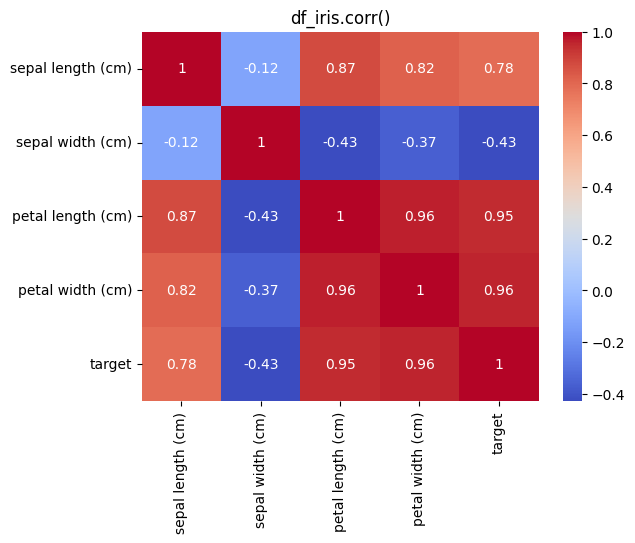

In [50]:
sns.heatmap(correlation_matrix,cmap='coolwarm',annot=True)
plt.title('df_iris.corr()')


Text(0.5, 1.0, 'Relationship between sepal length and petal length')

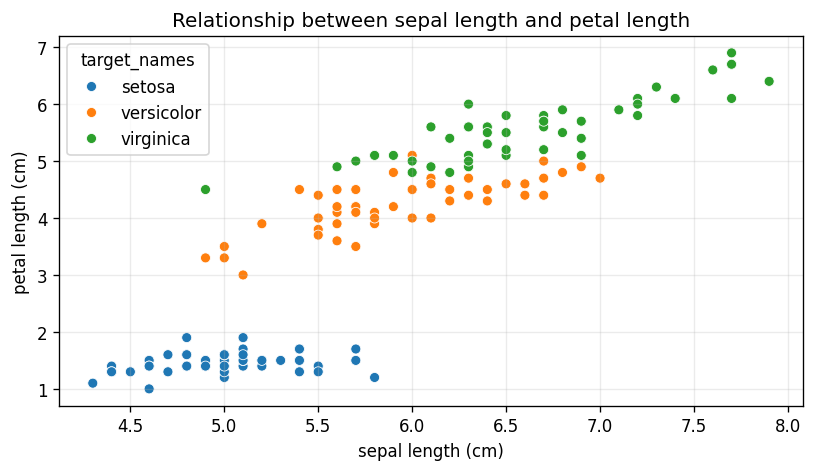

In [54]:
plt.figure(figsize=(8,4), dpi=120)
sns.scatterplot(data= df_iris,
                x='sepal length (cm)',
                y='petal length (cm)',
                hue='target_names'
                )
plt.grid(alpha=0.25)
plt.title('Relationship between sepal length and petal length')

<Axes: xlabel='petal width (cm)', ylabel='petal length (cm)'>

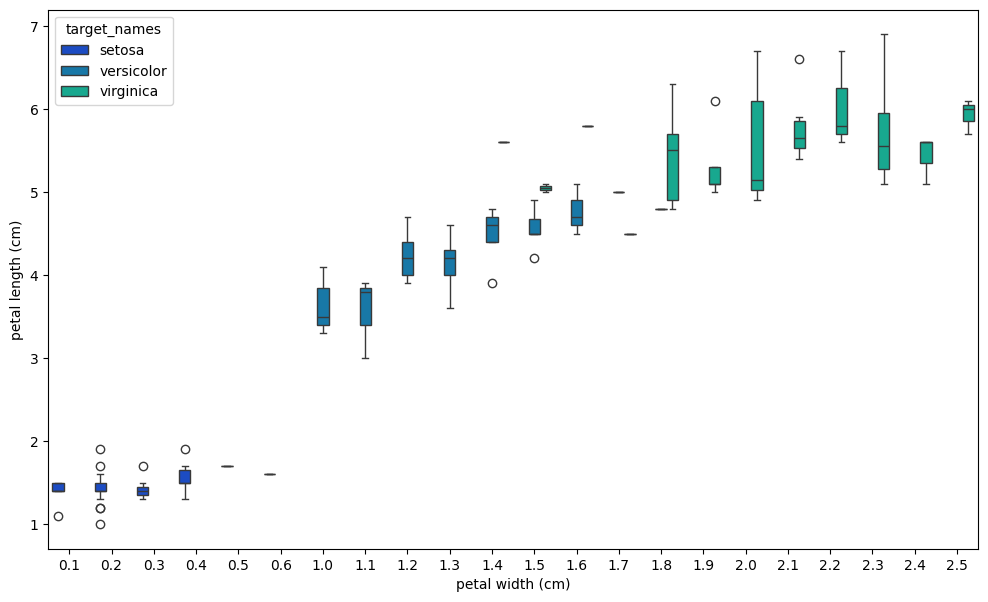

In [52]:
plt.figure(figsize=(12, 7))
sns.boxplot(x='petal width (cm)',y='petal length (cm)',data=df_iris,palette='winter',hue='target_names')

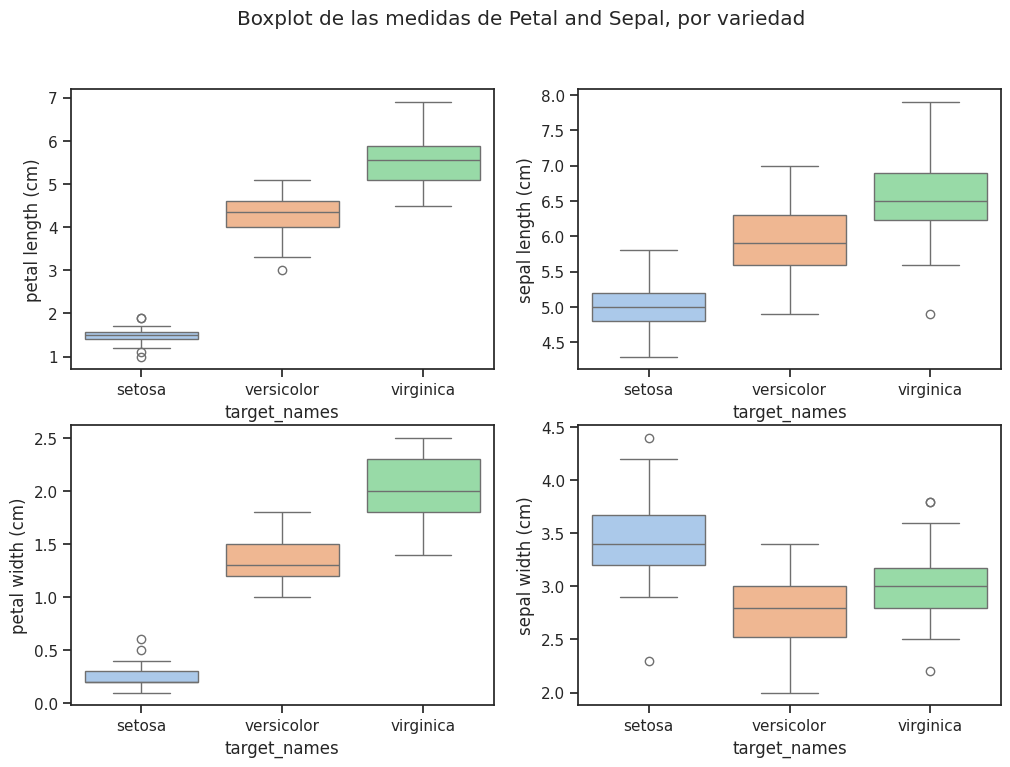

In [65]:
sns.set(style="ticks", palette="pastel")
f, axes = plt.subplots(2, 2, sharey=False, figsize=(12, 8))
sns.boxplot(x="target_names", y="petal length (cm)",hue = "target_names",data=df_iris, ax = axes[0,0])
sns.boxplot(x="target_names", y="sepal length (cm)",hue = "target_names", data=df_iris, ax=axes[0,1])
sns.boxplot(x="target_names", y="petal width (cm)",hue = "target_names",data=df_iris, ax=axes[1,0])
sns.boxplot(x="target_names", y="sepal width (cm)", hue = "target_names", data=df_iris, ax=axes[1,1])
f.suptitle("Boxplot de las medidas de Petal and Sepal, por variedad")
plt.show()

# Write down comments supporting your thoughts.

- Hay la misma cantidad de cada especie.
- Parece haber una relación lineal entre petal width(cm) y petal length(cm); a mayor de uno, mayor del otro.
- A su vez, parece haber una relación entre dichas variables y la variedad (setosa, versicolor, virginica) 
- No parece haber una relación lineal entre sepal width(cm) y sepal length(cm).
- También parece haber una relación lineal entre sepal length y petal length. También relacionado con la variedad (setosa, versicolor, virginica).
- El último diagrama de caja es muy útil para mostrar claramente las diferencias en la distribución de las mediciones entre las tres especies de iris del conjunto de datos. El iris setosa se distingue de las otras dos clases por sus pétalos mucho más pequeños. No parece haber muchos valores atípicos.